In [1]:
import sys
print(sys.executable)
print(sys.version)

/Users/abdur-rahman/Projects/music-recommendation-system/.venv/bin/python
3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 21.0.0 (clang-2100.0.123.102)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/dataset.csv")

print(f"Number of songs: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

df.head()

Number of songs: 114,000
Number of columns: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [5]:
df.isnull().sum().sort_values(ascending=False)

artists             1
album_name          1
track_name          1
Unnamed: 0          0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
track_id            0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate track IDs:", df["track_id"].duplicated().sum())
print("Unique track IDs:", df["track_id"].nunique())

Duplicate rows: 0
Duplicate track IDs: 24259
Unique track IDs: 89741


In [7]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [8]:
duplicate_tracks = df[df["track_id"].duplicated(keep=False)].sort_values("track_id")

duplicate_tracks[
    ["track_id", "track_name", "artists", "track_genre", "popularity"]
].head(20)

,track_id,track_name,artists,track_genre,popularity
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill,0
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul,0
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock,38
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska,38
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock,86
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alternative,86
2106,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alt-rock,86
33178,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,emo,58
94239,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,sad,58
97533,006rHBBNLJMpQs8fRC2GDe,Agora Estou Sofrendo - Ao Vivo,Calcinha Preta;Gusttavo Lima,sertanejo,47


In [9]:
df_clean = df.drop(columns=["Unnamed: 0"]).copy()

df_clean = df_clean.dropna(
    subset=["track_name", "artists", "album_name"]
)

print("Rows after removing missing values:", len(df_clean))

Rows after removing missing values: 113999


In [10]:
genre_map = (
    df_clean.groupby("track_id")["track_genre"]
    .agg(lambda genres: ", ".join(sorted(set(genres))))
)

df_clean = df_clean.drop_duplicates(
    subset="track_id",
    keep="first"
).copy()

df_clean["track_genre"] = df_clean["track_id"].map(genre_map)

In [11]:
print(f"Original rows: {len(df):,}")
print(f"Cleaned rows: {len(df_clean):,}")
print(f"Unique track IDs: {df_clean['track_id'].nunique():,}")
print(f"Duplicate track IDs: {df_clean['track_id'].duplicated().sum()}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

Original rows: 114,000
Cleaned rows: 89,740
Unique track IDs: 89,740
Duplicate track IDs: 0
Missing values: 0


In [12]:
df_clean.to_csv("../data/cleaned_spotify.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Exploratory Data Analysis

This section explores the distributions and relationships between Spotify audio features before building the recommendation model.

In [13]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

df_clean[audio_features].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,89740.0,0.562166,0.176692,0.000,0.45000,0.576000,0.692000,0.985
energy,89740.0,0.634458,0.256606,0.000,0.45700,0.676000,0.853000,1.000
loudness,89740.0,-8.498994,5.221518,-49.531,-10.32225,-7.185000,-5.108000,4.532
speechiness,89740.0,0.087442,0.113278,0.000,0.03600,0.048900,0.085900,0.965
acousticness,89740.0,0.328285,0.338321,0.000,0.01710,0.188000,0.625000,0.996
instrumentalness,89740.0,0.173415,0.323849,0.000,0.00000,0.000058,0.097625,1.000
liveness,89740.0,0.216971,0.194885,0.000,0.09820,0.132000,0.279000,1.000
valence,89740.0,0.469474,0.262864,0.000,0.24900,0.457000,0.682000,0.995
tempo,89740.0,122.058134,30.117651,0.000,99.26275,122.013000,140.077000,243.372


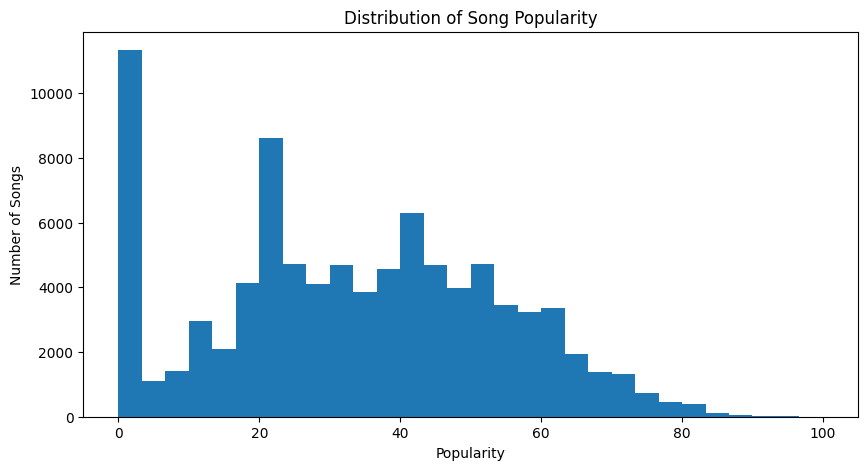

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_clean["popularity"],
    bins=30
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

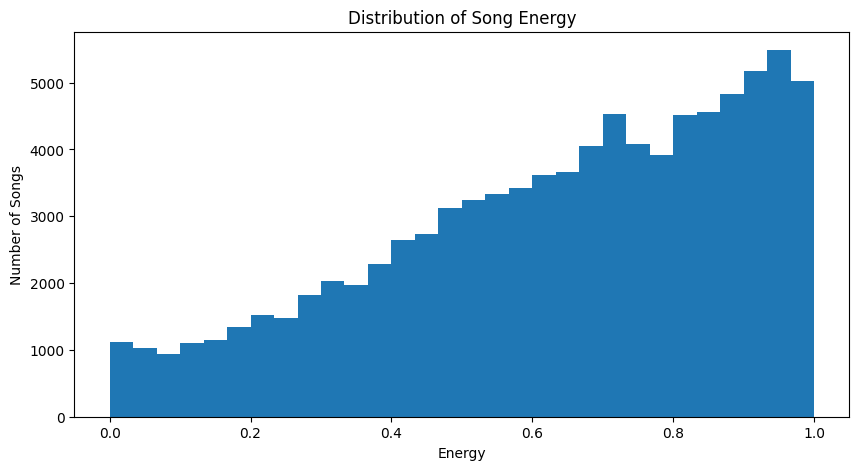

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_clean["energy"],
    bins=30
)

plt.title("Distribution of Song Energy")
plt.xlabel("Energy")
plt.ylabel("Number of Songs")

plt.show()

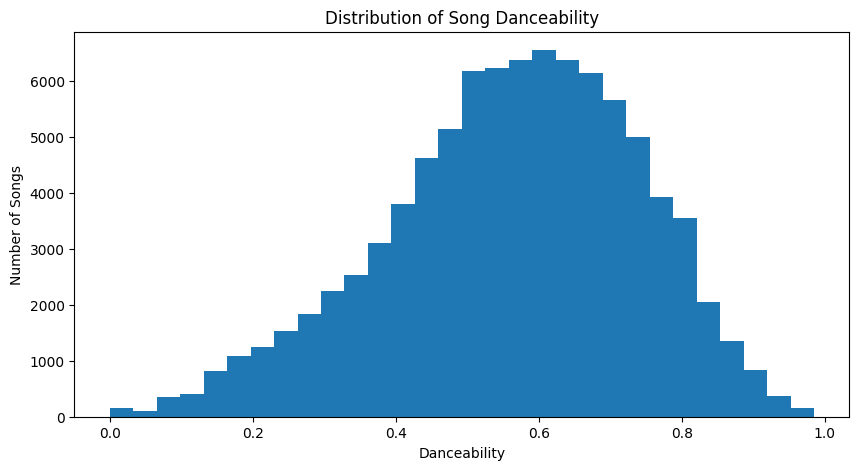

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_clean["danceability"],
    bins=30
)

plt.title("Distribution of Song Danceability")
plt.xlabel("Danceability")
plt.ylabel("Number of Songs")

plt.show()

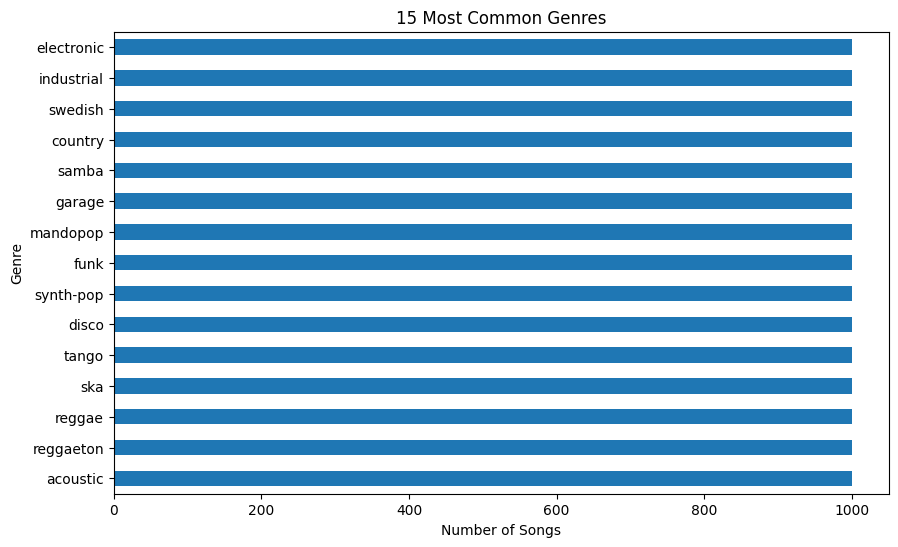

In [18]:
genre_counts = (
    df_clean["track_genre"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
)

genre_counts

plt.figure(figsize=(10, 6))

genre_counts.sort_values().plot(kind="barh")

plt.title("15 Most Common Genres")
plt.xlabel("Number of Songs")
plt.ylabel("Genre")

plt.show()

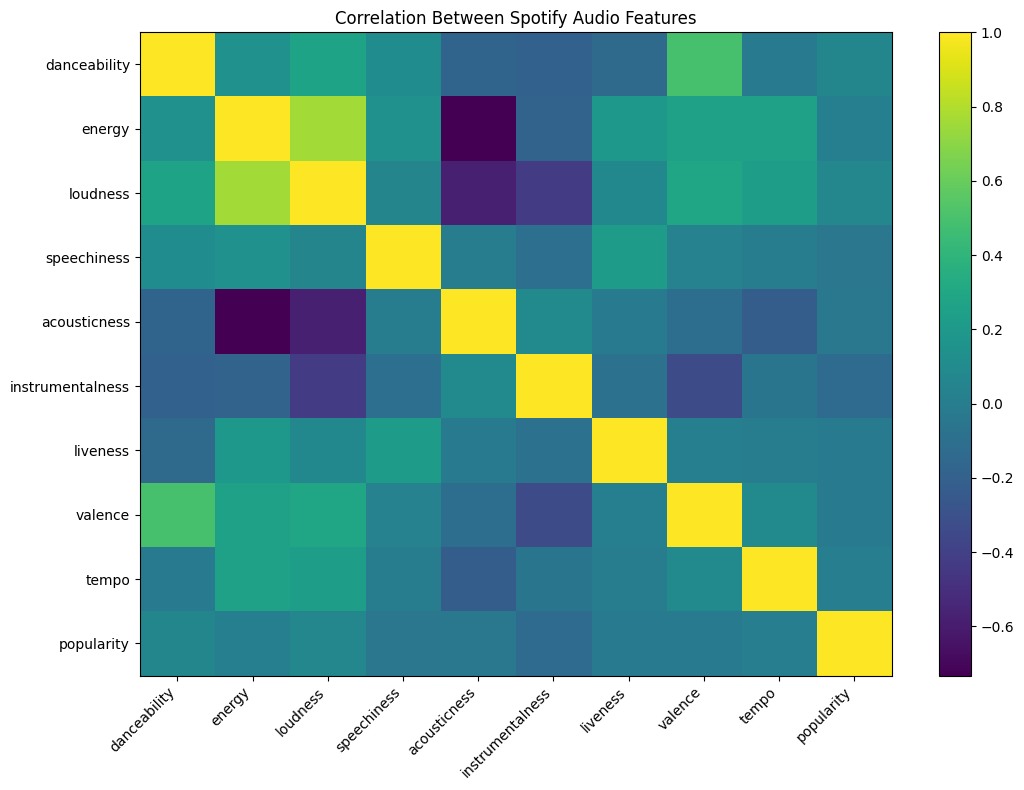

In [19]:
correlation_matrix = df_clean[
    audio_features + ["popularity"]
].corr()

correlation_matrix.round(2)

plt.figure(figsize=(11, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Between Spotify Audio Features")

plt.tight_layout()
plt.show()